In [1]:
import logging
from trails import Trails, lca, get_lcia_method_names, plot_temporal_scores
from datapackage import Package
from trails.logging import configure_trails_logging, trails_log_context

configure_trails_logging(file_level=logging.DEBUG)

dp = Package("datapackage.json")
#dp = Package("/Users/romain/GitHub/premise/dev/trails_2025-12-16.zip")
trails = Trails(dp, interpolate_annual=True)

methods = ["IPCC 2021 - climate change: fossil - global warming potential (GWP100)",]
#methods = ["IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",]

/Users/romain/micromamba/envs/trails/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


Loading matrices from data package          [1/3]
Loading indices from data package           [2/3]
Interpolating matrices to annual resolution [3/3]


In [2]:
ref_year = 2040

with trails_log_context(run_id="bev_vs_icev", case="ICEV"):
    results_by_year_ICEV, provenance = lca(
        trails,
        start_year=ref_year,
        start_act_idx=2,
        #start_act_idx=27825,
        methods=methods,
        max_depth=2,
        return_provenance=True,
        show_progress=True,
        min_amount=1e-18
    )

Temporal traversal: 392node [00:00, 895.72node/s]                               
Temporal LCA over years
0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:00:00


In [3]:
results_by_year_ICEV

{2024: {'fu': {0: 3.34581445882165e-10},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x13aa8d8d0>,
  'scores': 4.594918209477328e-06,
  'scores_per_root': {2: 0.0}},
 2025: {'fu': {0: 2.1817450068795097e-09},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x1388c5d50>,
  'scores': 2.9817179893143475e-05,
  'scores_per_root': {2: 0.0}},
 2026: {'fu': {0: 1.1079815287473593e-08},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x1387f9750>,
  'scores': 0.00015068548964336514,
  'scores_per_root': {2: 0.0}},
 2027: {'fu': {0: 4.3821522410780744e-08},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x138221390>,
  'scores': 0.000593051256146282,
  'scores_per_root': {2: 0.0}},
 2028: {'fu': {0: 1.3497978557097667e-07},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x139db1890>,
  'scores': 0.001817727810703218,
  'scores_per_root': {2: 0.0}},
 2029: {'fu': {0: 3.2379966796725057e-07},
  'fu_per_root': {2: {}},
  'lca': <bw2calc.lca.LCA at 0x12f5dbc

In [4]:
ref_year = 2040
results_static_ICEV = lca(
    trails,
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=2,
    return_provenance=False,
    show_progress=False,
    min_amount=1e-18,
    use_temporal_distributions=False
)

In [5]:
fig = plot_temporal_scores(
    results_by_year=results_by_year_ICEV,
    stacked=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2005, 2060),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=results_static_ICEV["results_by_solve_year"][ref_year]["scores"] - 0.14 + (0.14/2),
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.015,
    y2_max=0.20
)
fig.show()

ValueError: No scores_per_root found.

In [5]:
ref_year = 2040
results_by_year_BEV, provenance = lca(
    trails,
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=8,
    return_provenance=True,
    show_progress=False,
    min_amount=1e-18
)

In [6]:
results_static_BEV = lca(
    trails,
    start_year=ref_year,
    start_act_idx=2,
    methods=methods,
    max_depth=8,
    return_provenance=False,
    show_progress=False,
    min_amount=1e-18,
    use_temporal_distributions=False
)

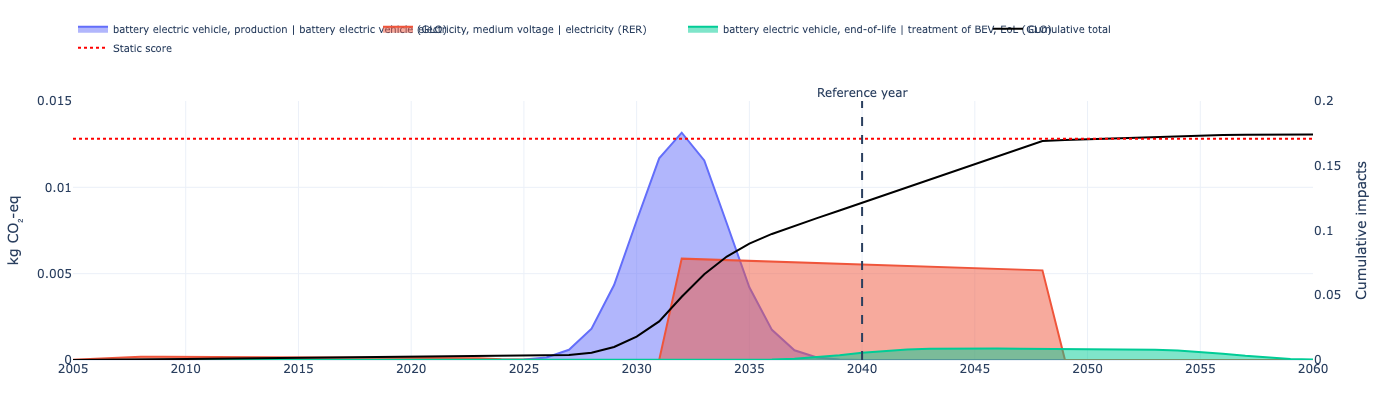

In [12]:
fig = plot_temporal_scores(
    results_by_year=results_by_year_BEV,
    stacked=False,
    trails=trails,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=400,
    year_tick=5,
    year_range=(2005, 2060),
    reference_year=ref_year,
    show_cumulative_axis=True,
    cumulative_axis_label="Cumulative impacts",
    legend_y=1.15,
    static_score=results_static_BEV[2040]["scores"],
    static_score_dash= "dot",
    static_score_color= "red",
    y_max=0.015,
    y2_max=0.20
)
fig.show()

In [6]:
from trails.plotting import plot_traversal_grid_flow
edges_by_depth = trails.collect_traversal_edges(
    start_year=2050,
    start_act_idx=13,
    amount=1.0,
    max_depth=5,
    min_amount=1e-18,
)

fig = plot_traversal_grid_flow(
    edges_by_depth=edges_by_depth,
    trails=trails,
    depths=None,                 
    include_all_activities=True,
    title="Traversal flows by depth",
    dot_size=5,
)

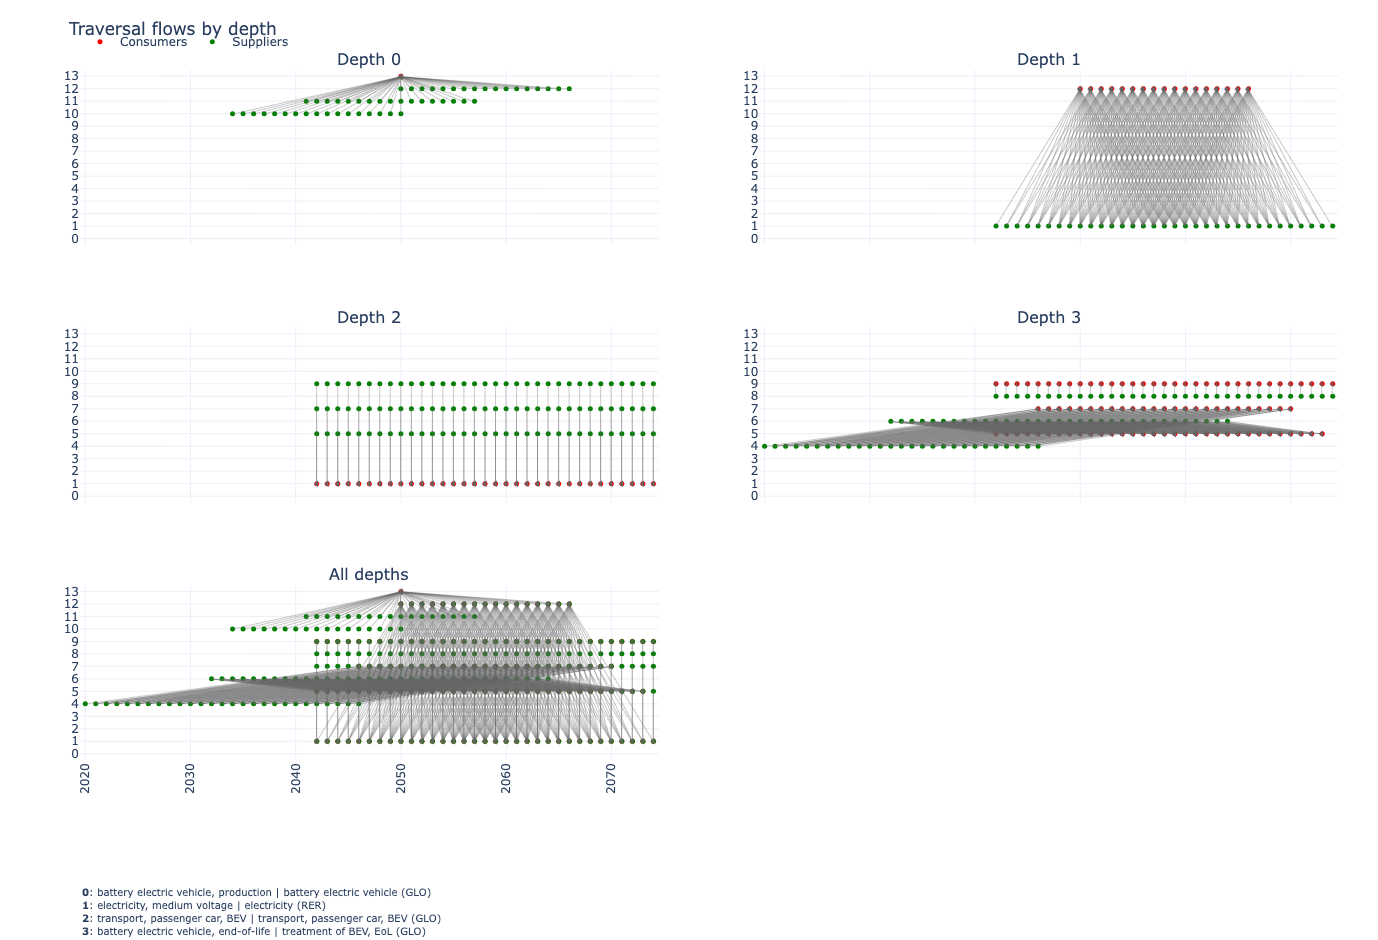

In [7]:
fig

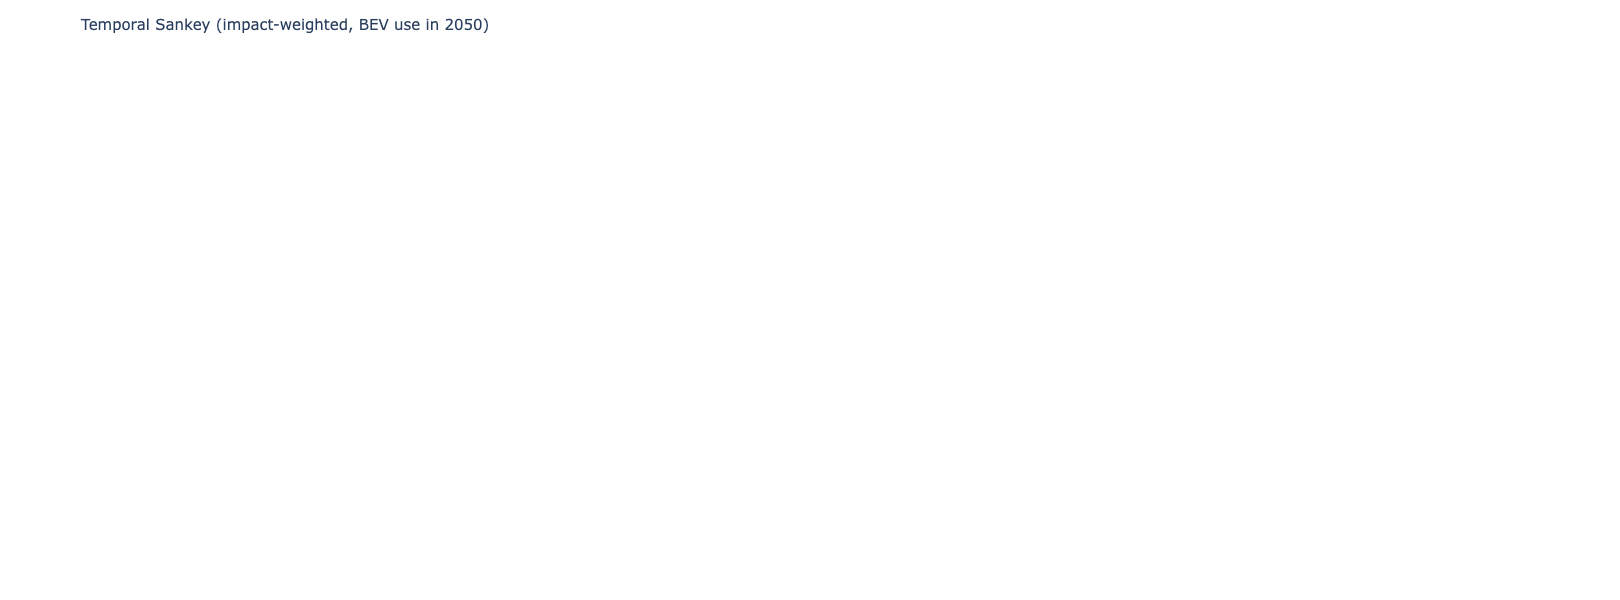

In [8]:
from trails.plotting import plot_temporal_sankey
fig = plot_temporal_sankey(
    provenance=provenance,
    trails=trails,
    start_year=2050,
    start_act_idx=2,
    methods=methods,
    top_n_paths=None,                # or None to show all
    title="Temporal Sankey (impact-weighted, BEV use in 2050)",
    amount_label="Impact (kg CO2-eq)",  # or whatever the method unit is
    fig_width=1600,
    fig_height=600,
)

fig.show()

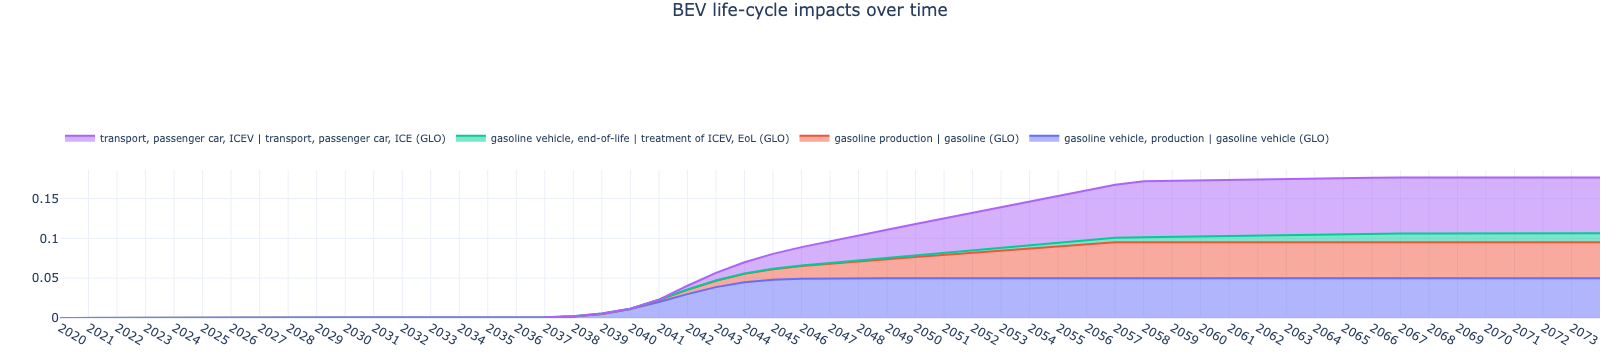

In [9]:
fig = plot_temporal_scores(
    results_by_year=results_by_year,
    trails=trails,
    title="BEV life-cycle impacts over time",
    method_label="kg CO₂-eq",
    cumulative=True
)
fig.show()

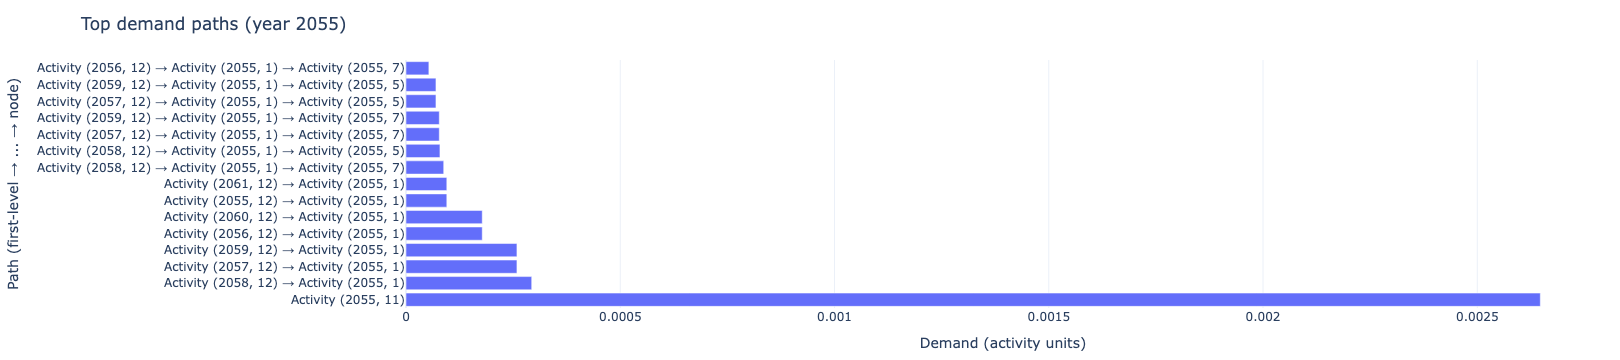

In [10]:
from trails.plotting import plot_top_paths_for_year
plot_top_paths_for_year(
    provenance=provenance,
    trails=trails,
    year=2055,
    top_n=15,
    title="Top demand paths",
    amount_label="Demand (activity units)",
)

In [11]:
fig_d2

NameError: name 'fig_d2' is not defined

In [ ]:
from trails.lca import build_datapackage_for_year_from_trails
from trails.lcia import get_lcia_methods

year = 2049  # or any year that appears in results

dp, tech_idx, bio_idx, uncertain_params = build_datapackage_for_year_from_trails(
    trails=trails,
    year=year,
    remove_uncertainty=True,
)

lca = results[year]["lca"]
biosphere_matrix_dict = lca.dicts.biosphere  # {flow_id: row index}

# Build the mapping expected by fill_characterization_factors_matrices
biosphere_dict_simple = {
    (name, comp, subcomp): idx
    for (name, comp, subcomp, unit), idx in bio_idx.items()
}

print("Sample biosphere flows from DB:")
for k in list(biosphere_dict_simple.keys())[:10]:
    print("  DB  :", k)

# Use the same 'methods' list you passed to temporal_lcia_from_trails
lcia_data = get_lcia_methods(methods=methods)

print("\nSample LCIA flows from first method:")
m0 = methods[0]
for k in list(lcia_data[m0].keys())[:10]:
    print("  LCIA:", k)

intersection = set(lcia_data[m0].keys()) & set(biosphere_dict_simple.keys())
print("\nNumber of matching flows:", len(intersection))
print("Some matches:", list(intersection)[:10])


In [ ]:
print("Sample bio_idx entries:")
for k, v in list(bio_idx.items())[:10]:
    print("  key:", k, "value:", v)


In [ ]:
result = trails.expand_temporal_exchanges(year=2050, act_idx=1, amount=1.0)
result

In [ ]:
frontier = trails.temporal_traversal(
    start_year=2050,
    start_act_idx=1,
    amount=1.0,
    max_depth=2,      # say 2 layers for now
    min_amount=1e-12,
)

len(frontier), list(frontier.items())[:10]


In [ ]:
dp = Package("datapackage.json")

In [ ]:
from trails import Trails

In [ ]:
trails = Trails(dp)

In [ ]:
a3.temporal_distributions

In [ ]:
a3.A.dtype

In [ ]:
a3.B.dtype

In [ ]:
a3.scenario_index

In [ ]:
a3.scenario_labels

In [ ]:
a3.activity_indices

In [ ]:
a3.biosphere_index